In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


In [56]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Initialize gates slightly negative → encourages pruning early
        self.gate_scores = nn.Parameter(torch.zeros(out_features, in_features))    
        
    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores*6)        
        pruned_weights = self.weight * gates
        return nn.functional.linear(x, pruned_weights, self.bias)

    def get_gate_values(self):
        return torch.sigmoid(self.gate_scores)

In [57]:
class PrunableMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_all_gates(self):
        return [layer.get_gate_values() for layer in self.modules() if isinstance(layer, PrunableLinear)]

In [58]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=256, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False)

In [61]:
def train_model(lambda_val, epochs=12):
    model = PrunableMLP().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            ce_loss = criterion(outputs, labels)

            #sparsity loss (on sigmoid gates)
            sparsity_loss = sum(torch.sigmoid(layer.gate_scores).mean()
                                for layer in model.modules()
                                if isinstance(layer, PrunableLinear))

            if epoch < 6:
                loss = ce_loss
            else:
                loss = ce_loss + lambda_val * 12 * sparsity_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"[λ={lambda_val}] Epoch {epoch+1}/{epochs} Loss: {total_loss:.2f}")

    return model


def evaluate(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, pred = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (pred == labels).sum().item()

    return 100 * correct / total


def sparsity(model, threshold=0.5):
    total, zero = 0, 0

    for g in model.get_all_gates():
        total += g.numel()
        zero += (g < threshold).sum().item()

    return 100 * zero / total

In [62]:
lambdas = [0.01, 0.05, 0.1]
results = []

best_model = None
best_acc = 0

for lam in lambdas:
    print(f"\nTraining λ = {lam}")
    model = train_model(lam, epochs=12)

    acc = evaluate(model)
    sp = sparsity(model)

    print(f"λ={lam} | Accuracy={acc:.2f}% | Sparsity={sp:.2f}%")

    results.append((lam, acc, sp))

    if acc > best_acc:
        best_acc = acc
        best_model = model


Training λ = 0.01
[λ=0.01] Epoch 1/12 Loss: 344.38
[λ=0.01] Epoch 2/12 Loss: 293.20
[λ=0.01] Epoch 3/12 Loss: 268.28
[λ=0.01] Epoch 4/12 Loss: 249.34
[λ=0.01] Epoch 5/12 Loss: 233.70
[λ=0.01] Epoch 6/12 Loss: 219.42
[λ=0.01] Epoch 7/12 Loss: 239.60
[λ=0.01] Epoch 8/12 Loss: 227.36
[λ=0.01] Epoch 9/12 Loss: 213.25
[λ=0.01] Epoch 10/12 Loss: 198.96
[λ=0.01] Epoch 11/12 Loss: 186.85
[λ=0.01] Epoch 12/12 Loss: 174.46
λ=0.01 | Accuracy=55.55% | Sparsity=66.45%

Training λ = 0.05
[λ=0.05] Epoch 1/12 Loss: 345.19
[λ=0.05] Epoch 2/12 Loss: 293.63
[λ=0.05] Epoch 3/12 Loss: 269.14
[λ=0.05] Epoch 4/12 Loss: 249.63
[λ=0.05] Epoch 5/12 Loss: 233.55
[λ=0.05] Epoch 6/12 Loss: 219.48
[λ=0.05] Epoch 7/12 Loss: 379.07
[λ=0.05] Epoch 8/12 Loss: 362.40
[λ=0.05] Epoch 9/12 Loss: 346.08
[λ=0.05] Epoch 10/12 Loss: 332.75
[λ=0.05] Epoch 11/12 Loss: 317.80
[λ=0.05] Epoch 12/12 Loss: 303.12
λ=0.05 | Accuracy=55.30% | Sparsity=68.73%

Training λ = 0.1
[λ=0.1] Epoch 1/12 Loss: 345.59
[λ=0.1] Epoch 2/12 Loss: 293

In [63]:
print("\nFINAL RESULTS")
for lam, acc, sp in results:
    print(f"Lambda: {lam} | Accuracy: {acc:.2f}% | Sparsity: {sp:.2f}%")


FINAL RESULTS
Lambda: 0.01 | Accuracy: 55.55% | Sparsity: 66.45%
Lambda: 0.05 | Accuracy: 55.30% | Sparsity: 68.73%
Lambda: 0.1 | Accuracy: 55.23% | Sparsity: 70.65%


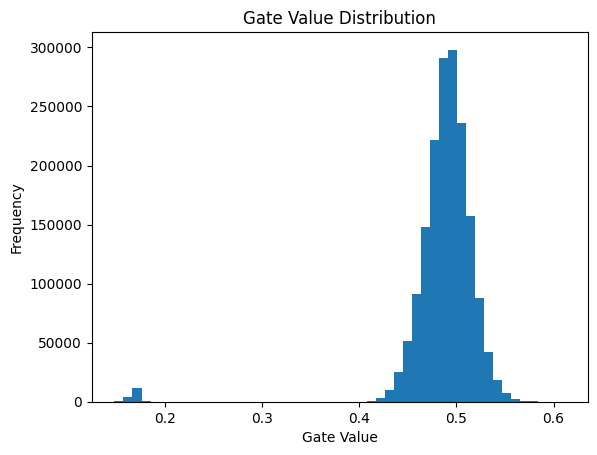

In [64]:
all_gates = torch.cat([g.flatten().cpu() for g in best_model.get_all_gates()])

plt.hist(all_gates.detach().numpy(), bins=50)
plt.title("Gate Value Distribution")
plt.xlabel("Gate Value")
plt.ylabel("Frequency")
plt.show()